In [2]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Desktop/Waterloo/Masters/Andrea_flinch_scripts/scripts`


In [6]:
Pkg.instantiate()
Pkg.resolve()

  No Changes to `~/Desktop/Waterloo/Masters/Andrea_flinch_scripts/scripts/Project.toml`
  No Changes to `~/Desktop/Waterloo/Masters/Andrea_flinch_scripts/scripts/Manifest.toml`


In [7]:
using Distributions
using LinearAlgebra
using StatsFuns
using StatsBase

using LogDensityProblems
using LogDensityProblemsAD
using AbstractDifferentiation
using MCMCDiagnosticTools
using AdvancedHMC
using MicroCanonicalHMC
using Pathfinder
using Transducers

using Healpix
using HealpixMPI
using MPI

using Plots
using StatsPlots
using LaTeXStrings
using DataFrames

using Random
using ProgressMeter
using BenchmarkTools
using NPZ
using CSV
using Test

using Zygote: @adjoint
using Zygote
using ChainRules.ChainRulesCore

include("AD_parallSHT.jl")
include("gen_datatest.jl")
include("reparam.jl")
include("utils.jl")
include("inference_model.jl")
include("neglogproblem.jl")

nℓπ_grad (generic function with 1 method)

In [8]:
# using Turing
# using Capse
using NPZ
# # using PlanckLite
# using BenchmarkTools
# using Plots
# using Optim
# using ForwardDiff
# using Pathfinder
# #using MicroCanonicalHMC
# #using Transducers
# using StatsPlots
# #using PairPlots
# #using LaTeXStrings
# #using CairoMakie
# using MCMCChains
using PSIS
# include("utils.jl");
using ArviZ
using ArviZPythonPlots
using LinearAlgebra
using IrrationalConstants
using DimensionalData
using Statistics
using Plots

In [9]:
Threads.nthreads()

4

In [10]:
matrix_1 = npzread("/Users/ethansmith/Desktop/Waterloo/Masters/Andrea_flinch_scripts/scripts/MPI_chains/6IeXJ_mask_NUTS_nside_16.npy")
matrix_2 = npzread("/Users/ethansmith/Desktop/Waterloo/Masters/Andrea_flinch_scripts/scripts/MPI_chains/sLl8l_mask_NUTS_nside_16.npy")
matrix_3 = npzread("/Users/ethansmith/Desktop/Waterloo/Masters/Andrea_flinch_scripts/scripts/MPI_chains/tZ7ZQ_mask_NUTS_nside_16.npy")
sampled_params = hcat(matrix_1, matrix_2, matrix_3)

1056×3000 Matrix{Float64}:
  -0.705178   -0.153022   -0.218566  …   -0.113412     -0.110324
  -1.31162    -0.638236   -0.274903      -0.00156193    0.0053253
  -0.585917   -0.775259   -0.575984      -0.00778132   -0.00429657
  -1.40335    -1.14839    -0.721023       0.00208482    0.000948992
 -10.7924    -12.5553    -12.3114       -10.5754      -10.6021
 -17.4856    -16.786     -16.6668    …  -16.856       -16.9318
   0.763131   -0.679599    1.14215        0.62343       0.580159
  -3.78524    -4.21772    -1.4408        -4.10684      -4.10474
  16.6806     14.8913     17.4784        12.6142       12.6227
  16.2934     14.5763     16.4857        13.9287       13.9398
 -18.3184    -18.0485    -18.0054    …  -20.161       -20.248
 -11.5053    -11.5445    -12.4555       -12.9857      -12.968
   4.47511     3.86129     4.08119        4.6411        4.62893
   ⋮                                 ⋱                
  -2.16733    -2.19617    -2.16781       -2.24927      -2.24551
  -2.51698    -2.59

In [11]:
seed = 1123
Random.seed!(seed)

#   RESOLUTION PARAMETERS
nside = 16
lmax = 2*nside - 1

MPI.Init()

comm = MPI.COMM_WORLD
crank = MPI.Comm_rank(comm)
csize = MPI.Comm_size(comm)
root = 0
ncore = 32

#   REALIZATION MAP
realiz_Cl, realiz_HAlm, realiz_HMap = Realization("Capse_fiducial_Dl.csv", nside, lmax, seed)
realiz_θ = vcat(x_vecmat2vec(from_healpix_alm_to_alm([realiz_HAlm], lmax, 1, comm, root=root), lmax, 1, comm, root=root), Cl2Kl(realiz_Cl))

d = length(realiz_θ)

#   SURVEY MASK
mask_512 = readMapFromFITS("wmap_temperature_kq85_analysis_mask_r9_9yr_v5.fits",2,Float64)
mask_nside = udgrade(nest2ring(mask_512), nside)
for i in 1:length(mask_nside.pixels)
    if mask_nside.pixels[i]<=0.5
        mask_nside.pixels[i]=1
    else
        mask_nside.pixels[i]=0
    end
end

#   GENERATED DATA MEASUREMENTS
#   Noise
ϵ=150
N = ϵ*ones(nside2npix(nside))
N[mask_nside.==1] .= 5*10^4
#   Gaussian beam and pixel window function
Bl = ones(length(realiz_Cl))#gaussbeam(0.001, lmax, pol=false)
Pl = ones(length(realiz_Cl))#pixwin(nside, pol=false)[1:lmax+1]
BP_l = Bl.*Pl

#   Data Map
gen_Cl, gen_HAlm, gen_HMap = Measurement(realiz_Cl, Bl, Pl, mask_nside, N, nside, lmax, seed)
gen_θ = vcat(x_vecmat2vec(from_healpix_alm_to_alm([gen_HAlm], lmax, 1, comm, root=root), lmax, 1, comm, root=root), Cl2Kl(gen_Cl))
invN_HMap = HealpixMap{Float64,RingOrder}(1 ./ N)

#   STARTING POINT
start_Cl, start_HAlm, start_HMap = StartingPoint(gen_Cl, nside)
start_θ = vcat(x_vecmat2vec(from_healpix_alm_to_alm([start_HAlm], lmax, 1, comm, root=root), lmax, 1, comm, root=root), Cl2Kl(start_Cl))

#   PROMOTE HEALPIX.MAP TO HEALIPIXMPI.DMAP
gen_DMap = DMap{RR}(comm)
invN_DMap = DMap{RR}(comm)
HealpixMPI.Scatter!(gen_HMap, gen_DMap, comm, clear=true)
HealpixMPI.Scatter!(invN_HMap, invN_DMap, comm, clear=true)

helper_DMap = deepcopy(gen_DMap)

DMap: I am task 0 of 1, I work on 63 rings of 63
DMap: I am task 0 of 1, I work on 63 rings of 63


DMap{RR, Float64}([0.0; 0.0; … ; 106.75576281525872; 57.76576547614584;;], GeomInfoMPI(MPI.Comm(1140850688), 16, 64, [1.5707963267948966, 1.5291175943723188, 1.6124750592174744, 1.4873662401842815, 1.6542264134055116, 1.445468495626831, 1.696124157962962, 1.4033482475752073, 1.7382444060145859, 1.3609257345321588  …  0.25585245340993723, 2.885740200179856, 0.20448019896853478, 2.9371124546212584, 0.15324300949611616, 2.988349644093677, 0.10210642238260403, 3.039486231207189, 0.05103657515266638, 3.090556078437127], [32, 31, 33, 30, 34, 29, 35, 28, 36, 27  …  5, 59, 4, 60, 3, 61, 2, 62, 1, 63], [1, 65, 129, 193, 257, 321, 385, 449, 513, 577  …  2953, 2973, 2993, 3009, 3025, 3037, 3049, 3057, 3065, 3069], [64, 64, 64, 64, 64, 64, 64, 64, 64, 64  …  20, 20, 16, 16, 12, 12, 8, 8, 4, 4], [1.5707963267948966, 1.5291175943723188, 1.6124750592174744, 1.4873662401842815, 1.6542264134055116, 1.445468495626831, 1.696124157962962, 1.4033482475752073, 1.7382444060145859, 1.3609257345321588  …  0.25

In [ ]:
# θ = sampled_params[:,1]
# alm = θ[1:length(θ)-lmax-1]
# sample_alm = x_vec2vecmat(alm, lmax, 1, comm, root=root)
# sample_HAlm = from_alm_to_healpix_alm(sample_alm, lmax, 1, comm, root=root)[1]
# sample_DAlm = HAlm2DAlm(sample_HAlm, comm; clear=true, root=root)

In [ ]:
# NLL_Pixel(sample_DAlm, helper_DMap, ncore, gen_DMap, invN_DMap, BP_l, 1354)

In [12]:
NLLs = Matrix{Any}(undef, 3072, 3000)

for n in 1:3000
    Threads.@threads for i in 1:length(gen_DMap.pixels)
        θ = sampled_params[:,n]
        alm = θ[1:length(θ)-lmax-1]
        sample_alm = x_vec2vecmat(alm, lmax, 1, comm, root=root)
        sample_HAlm = from_alm_to_healpix_alm(sample_alm, lmax, 1, comm, root=root)[1]
        sample_DAlm = HAlm2DAlm(sample_HAlm, comm; clear=true, root=root)
        NLL = NLL_Pixel(sample_DAlm, helper_DMap, ncore, gen_DMap, invN_DMap, BP_l, i)
        NLLs[i,n] = NLL
    end
end

DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am ta

Excessive output truncated after 524331 bytes.

DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am task 0 of 1, I work on 32 m's of 31
DAlm: I am ta

In [13]:
NLLs

3072×3000 Matrix{Any}:
  nothing     nothing     nothing    …   nothing     nothing      nothing
  nothing     nothing     nothing        nothing     nothing      nothing
  nothing     nothing     nothing        nothing     nothing      nothing
  nothing     nothing     nothing        nothing     nothing      nothing
  nothing     nothing     nothing        nothing     nothing      nothing
  nothing     nothing     nothing    …   nothing     nothing      nothing
  nothing     nothing     nothing        nothing     nothing      nothing
  nothing     nothing     nothing        nothing     nothing      nothing
  nothing     nothing     nothing        nothing     nothing      nothing
  nothing     nothing     nothing        nothing     nothing      nothing
  nothing     nothing     nothing    …   nothing     nothing      nothing
  nothing     nothing     nothing        nothing     nothing      nothing
  nothing     nothing     nothing        nothing     nothing      nothing
 ⋮             

In [14]:
nothing_count = 0
something_count = 0
for i in 1:3072
    for j in 1:3000
        if NLLs[i,j] == nothing
            nothing_count += 1
        else
            something_count += 1
        end
    end
end

println(nothing_count)
println(something_count)
#unmasked_pixels = Int64(something_count / 1000)

2064000
7152000


In [15]:
switch_vector = Vector{Int64}()
for i in 1:3071
    if (NLLs[i,1] == nothing && NLLs[i+1, 1] != nothing) || (NLLs[i,1] != nothing && NLLs[i+1, 1] == nothing)
        append!(switch_vector, i)
    end
end
println(length(switch_vector))
println(switch_vector)

261
[29, 30, 96, 97, 102, 104, 105, 106, 107, 108, 157, 158, 220, 224, 226, 234, 236, 238, 241, 242, 273, 275, 279, 281, 284, 285, 331, 332, 348, 368, 369, 371, 372, 373, 392, 394, 402, 405, 407, 410, 411, 413, 415, 416, 418, 423, 454, 455, 457, 465, 476, 486, 487, 491, 493, 495, 496, 502, 518, 519, 520, 522, 524, 527, 529, 540, 545, 546, 549, 553, 561, 562, 563, 566, 582, 595, 597, 599, 600, 601, 603, 620, 622, 624, 625, 632, 643, 644, 645, 650, 651, 657, 658, 668, 679, 681, 683, 684, 689, 695, 697, 698, 708, 709, 710, 723, 724, 748, 752, 761, 769, 772, 773, 777, 778, 784, 785, 795, 797, 798, 801, 802, 807, 809, 810, 812, 817, 825, 830, 832, 836, 837, 838, 851, 853, 877, 880, 887, 888, 890, 893, 894, 896, 897, 898, 913, 914, 924, 925, 926, 931, 932, 935, 941, 945, 955, 956, 960, 964, 965, 966, 979, 980, 1005, 1007, 1015, 1016, 1017, 1018, 1019, 1024, 1025, 1026, 1052, 1053, 1054, 1058, 1060, 1063, 1068, 1073, 1083, 1084, 1088, 1092, 1093, 1095, 1134, 1136, 1143, 1144, 1148, 1152, 1183

In [16]:
unmasked_pixels = 0
for i in 1:3072
    if NLLs[i, 1] != nothing
        unmasked_pixels += 1
    end
end

unmasked_NLLs = Matrix{Float64}(undef, unmasked_pixels, 3000)
unmasked_pixels = 0
for i in 1:3072
    if NLLs[i, 1] != nothing
        unmasked_pixels += 1
        unmasked_NLLs[unmasked_pixels,:] = NLLs[i,:]
    end
end

In [17]:
unmasked_NLLs

2384×3000 Matrix{Float64}:
 0.133932    0.377849    0.000257037  …  1.47115     1.42944      1.4892
 0.600532    0.481881    0.0532959       0.0601658   0.0485636    0.0544121
 0.0857627   0.223259    0.136825        0.0287205   0.022616     0.0271412
 1.00914     3.29786     0.0494529       0.106361    0.108673     0.111739
 0.0113183   1.14896     0.169435        1.31095     1.31301      1.19917
 2.99992     1.46265     0.53449      …  0.298995    0.286082     0.250614
 1.3802      0.205139    0.451411        0.00464256  0.000712964  0.00429328
 0.488897    1.20394     0.0603327       1.33761     1.31717      1.37452
 0.772357    0.149169    0.0632032       0.666039    0.647882     0.686533
 0.146153    0.0854021   0.00802456      0.799767    0.749397     0.742459
 0.686226    0.784932    1.90332      …  0.202659    0.212807     0.297821
 0.101911    0.316787    1.48392         0.68595     0.702281     0.628292
 0.831335    0.742527    0.0173857       0.0158734   0.0247181    0.02579

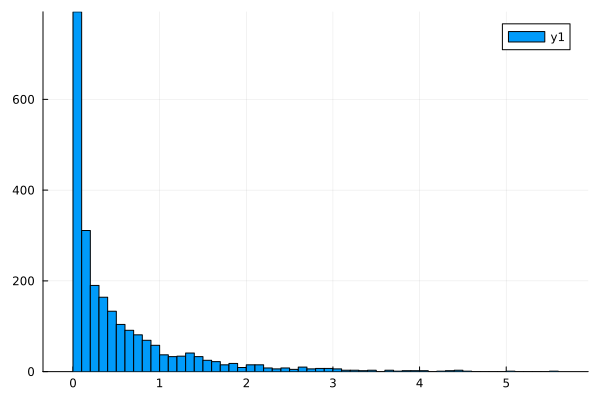

In [18]:
histogram(unmasked_NLLs[:,1])

In [19]:
psis_result = Vector{PSISResult{Float64, Vector{Float64}, Int64, Int64, PSIS.GeneralizedPareto{Float64}}}(undef, 2384);
for i in 1:unmasked_pixels
    psis_result[i] = psis(unmasked_NLLs[i,:])
end

┌ Warning: Pareto shape k = 0.87 > 0.7. Resulting importance sampling estimates are likely to be unstable.
└ @ PSIS ~/.julia/packages/PSIS/jp3Nb/src/core.jl:365
┌ Warning: Pareto shape k = 0.7 > 0.7. Resulting importance sampling estimates are likely to be unstable.
└ @ PSIS ~/.julia/packages/PSIS/jp3Nb/src/core.jl:365
┌ Warning: Pareto shape k = 0.96 > 0.7. Resulting importance sampling estimates are likely to be unstable.
└ @ PSIS ~/.julia/packages/PSIS/jp3Nb/src/core.jl:365
┌ Warning: Pareto shape k = 0.87 > 0.7. Resulting importance sampling estimates are likely to be unstable.
└ @ PSIS ~/.julia/packages/PSIS/jp3Nb/src/core.jl:365
┌ Warning: Pareto shape k = 1.1 > 1. Corresponding importance sampling estimates are likely to be unstable and are unlikely to converge with additional samples.
└ @ PSIS ~/.julia/packages/PSIS/jp3Nb/src/core.jl:363
┌ Warning: Pareto shape k = 0.96 > 0.7. Resulting importance sampling estimates are likely to be unstable.
└ @ PSIS ~/.julia/packages/PSIS/jp3

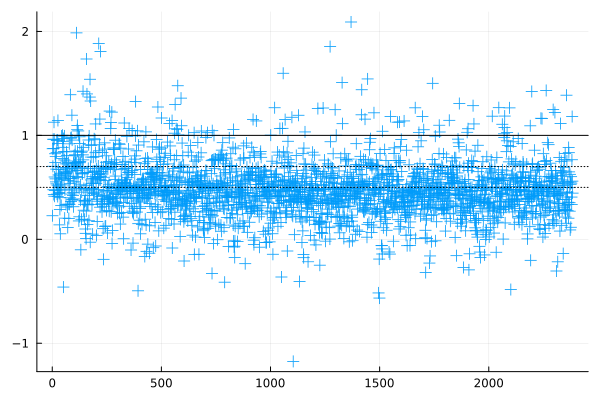

In [20]:
pareto_shapes = Vector{Float64}()
for i in 1:unmasked_pixels
    append!(pareto_shapes, psis_result[i].pareto_shape)
end

Plots.scatter(pareto_shapes; marker =:+, markersize=6, legend = false, linewidth=2)
hline!([0.5,0.7], linestyle=:dot, color =:black)
hline!([1.0], linestyle=:solid, color=:black)

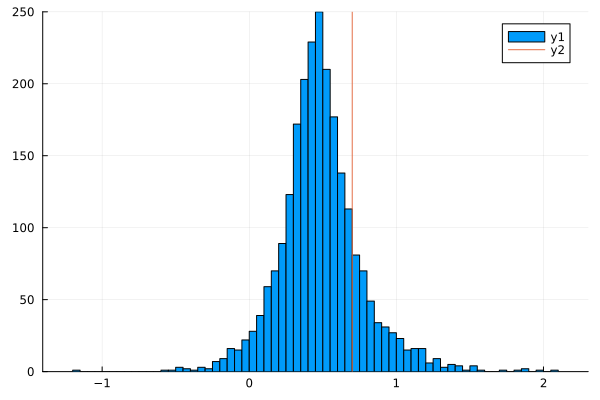

In [23]:
histogram(pareto_shapes)
vline!([0.7])

In [31]:
failure_count= 0 
for i in 1:2384
    if pareto_shapes[i] > 0.7
        failure_count += 1
    end
end
println(failure_count)
println(failure_count / 2384)

401
0.16820469798657717


In [ ]:
Random.seed!(1234)

In [ ]:
draws = Vector{Vector{Float64}}(undef, 1000)
for i in 1:1000
    dist = 
    draws[i] 

In [ ]:
draws = Vector{Vector{Float64}}(undef, num_steps*num_chains)

for i in 1:num_steps
    for j in 1:num_chains
        new_µ = vec(µ_array[i,j,:])
        dist = MvNormal(new_µ, S_pd)
        draws[(i-1)*num_chains + j] = rand(dist)
    end
end